<a href="https://colab.research.google.com/github/DanielHidalgoChica/VC_p1/blob/master/P1_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
ESTA ES UNA CELDA ARRIBA: PRIMER CAMBIO

# Visión por Computador - Práctica 1 - Introducción a OpenCV, Uso Responsable de Herramientas de IA Generativa, y Primeros Pasos con Procesado de Imagen

#### 5 puntos   |   Fecha de entrega: 18 de octubre de 2026, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2627.ugr.es/

### Estudiante: <mark>POR FAVOR, INTRODUZCA AQUÍ SU NOMBRE COMPLETO</mark>



---

## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.






### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2627.ugr.es/mod/folder/view.php?id=83733):
-  Introducción a Python: https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/2.%20Introducci%C3%B3n%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf(y Notebook asociado: https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2627.ugr.es/pluginfile.php/153447/mod_folder/content/0/Algunas%20ideas%20sobre%20c%C3%B3mo%20elaborar%20un%20informe%20acad%C3%A9mico-cient%C3%ADfico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2627.ugr.es/pluginfile.php/153448/mod_folder/content/0/Ejemplo_Otsu.ipynb



---



## Funciones de apoyo y conexión con Google Drive

In [ ]:
# We start by getting access to the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# We import the main potential modules to use
import os,sys
import cv2, numpy as np, math
from matplotlib import pyplot as plt
# change directory
%cd '/content/drive/My Drive'
#  the current directory
%pwd

# This allows to display images  and to save  them in cells
%matplotlib inline
# this definition allows to read files in a specific path
get_image = lambda route: os.path.join('/content/drive/My Drive/images', route)

/content/drive/My Drive


Las funciones que se incluyen a continuación, se proporcionan como ayuda/apoyo para el estudiante. **En caso de que el alumnado prefiera utilizar otras funciones para lectura, normalización y visualización de imágenes, tiene total libertad para hacerlo, pero sí debe justificar y explicar razonadamente el motivo de dicho cambio y describir las modificaciones realizadas.**

Recuérdese que todas las imágenes a emplear durante las prácticas de todo el curso se pueden encontrar en el enlace de Google Drive indicado en PRADO: https://pradogrado2627.ugr.es/mod/url/view.php?id=83732 En concreto, https://drive.google.com/drive/folders/1UtvY8q6w1Cz9a9T9zxIqSweoRLgNwoW-

In [ ]:
'''
This function receives a string with the filename of the image to read,
and a flag indicating if we want to read it in color/RGB (flagColor=1) or gray level (flagColor=0)

Example of use:
im1=readIm(get_image('apple.jpg'),0)

'''
def readIm(filename, flagColor=1):
  # cv2 reads BGR format
  im=cv2.imread(filename)
  if im is None:
    raise FileNotFoundError(f'No se ha podido leer la imagen: {filename}')
  # change to  RGB and return the image
  if(flagColor):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  # change from BGR to grayscale instead if flag is 0
  return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

In [ ]:
'''
This function receives an array of arbitrary real numbers (that could include even negative values),
and returns an 'image' in the range [0,1].
flag_GLOBAL allows the user to normalize the whole image (including all channels) or to normalize
each channel/band independently.
'''
def rangeDisplay01(im, flag_GLOBAL= True):
  im = im.astype(float)
  if flag_GLOBAL:
    vmin = im.min()
    vmax = im.max()
    if vmax == vmin:
      return np.zeros_like(im, dtype=float)
    im = (im - vmin) / (vmax - vmin)
  else:
    # bands normalization
    for band in range(im.shape[2]):
      im[:, :, band] = (im[:, :, band] - im[:, :, band].min())/(im[:, :, band].max() - im[:, :, band].min())
      # Note: remember that, for plt.imshow with RGB data, the valid range is [0..1] for floats and [0..255] for integers.
  return im

In [ ]:
'''
This function displays a single image, including a title, using a magnification factor.

Example of use:
im1=readIm(get_image('apple.jpg'),0)
displayIm(im1,'Manzana',0.5)

'''
def displayIm(im, title='Result',factor= 2):
  # First normalize range
  max=np.max(im)
  min=np.min(im)
  if min<0 or max>255:
    im=rangeDisplay01(im,flag_GLOBAL=True)
  if len(im.shape) == 3:
    # im es tribanda
    plt.imshow(im, cmap='jet')
  else:
    # im es monobanda
    plt.imshow(im, cmap='gray')
  figure_size = plt.gcf().get_size_inches()
  plt.gcf().set_size_inches(factor * figure_size)
  plt.title(title)
  plt.xticks([]), plt.yticks([]) # eliminamos numeración
  plt.show()

In [ ]:
'''
This function displays multiple images (including a title and using a magnification factor)
of equal size. The input to the function is a list of images.

Example of use:
im1=readIm(get_image('apple.jpg'),1)
images = [im1,im1,im1]

displayMI_ES(images, title='Manzanas',factor=1)

IMPORTANT NOTE: it is important to notice that this function stacks all images
and later call displayIm(). This implies that the normalization (rangeDisplay01()) is done
at the very end of the process. As a consequence, if the stacked images have different
range values they can be displayed in a "weird" way (with black regions (pixel value = 0)
looking grey). In case the visualization seems to be a problem, a possible solution
would be to create vim using vim.append(rangeDisplay01(...)). In this way, all images
would be on the same range of values (negative values around 0 (black),
0 values around 0.5 (grey), and positive values closer to 1 (white))

'''
def displayMI_ES(vim, title='Result',factor=2):
  # We set the maximun number of images to concatenate by columns
  maxcolumns=4
  # number of images to display
  numberim=len(vim)
  # The simplest case, one row: the maximum number of columns is larger than the images to stack
  # This is, by default, we put together the images column-wise
  if len(vim) < maxcolumns:
    out=vim[0]
    for item in range(1,len(vim)):
      #displayIm(out,str(item),1)
      out=np.hstack((out,vim[item]))

  # Else, if maxcolumns is smaller or equal than the number of images to stack
  else:
    # We check if all rows and columns are going to be 'busy', or if otherwise we need an extra-row
    if np.mod(len(vim),maxcolumns)== 0:
      maxrows=numberim//maxcolumns
    else:
      maxrows=numberim//maxcolumns+1

    # we build up the first block-row
    out=vim[0]
    for item in range(1,maxcolumns):
      out=np.hstack((out,vim[item]))
    # We build up the rest of block-rows
    for block in range(1,maxrows):
      #print(block)
      row=vim[block*maxcolumns]
      for item in range(1,maxcolumns):
        # We still have images to stack
        if block*maxcolumns+item < numberim:
          row=np.hstack((row,vim[block*maxcolumns+item]))
        # We do not have more images, and we have to fill with black
        else:
          row=np.hstack((row,np.zeros(vim[0].shape,dtype=vim[0].dtype)))
          #print(row.dtype)
          # if we don't include ',dtype=vim[0].dtype', np.zeros will include float
          # numbers in the matrix. This will make that the whole matrix will be
          # considered as floats, and values larger than 1 will be clipped to 1,
          # displaying an almost totally white image
      # add the new block-row
      out=np.vstack((out,row))
  return displayIm(out,title,factor)

# <font color='blue'>**Ejercicio 1: Análisis crítico de textos científicos, uso responsable de herramientas de IA generativa, y documentación adecuada del trabajo realizado** (2 puntos)

<font color='blue'>El objetivo es aprender a utilizar la IA generativa como herramienta de apoyo de forma crítica, transparente y responsable. La responsabilidad sobre el contenido entregado corresponde en todo momento al estudiante.

<font color='blue'>Tanto en este ejercicio como en cualquier otro (salvo que se indique lo contrario) puedes utilizar uno o varios LLMs, sea para realizar una búsqueda bibliográfica, comprensión y análisis de artículos, organización de ideas, generación de tablas, revisión lingüística o incluso redacción parcial del texto. Sin embargo, deberás indicar explícitamente qué partes del trabajo has realizado personalmente y cuáles han sido realizadas o asistidas mediante IA generativa. En este sentido, al final de cada ejercicio, en caso de que ya no lo hayas explicado en otra parte del propio ejercicio,  puedes incluir un breve apartado titulado **«Uso de IA generativa»**, en el que indiques:
* <font color='blue'>qué herramienta o herramientas has utilizado;
* para qué tareas las has utilizado;
* algunos de los prompts más relevantes empleados;
* y qué información proporcionada por el LLM has tenido que corregir, descartar o verificar.

<font color='blue'>El objetivo no es evitar el uso de estas herramientas, sino aprender a utilizarlas de forma **transparente, crítica y verificable**.









## <font color='blue'>A) Uso crítico de LLMs: coste energético de la IA generativa (1 punto)

<font color='blue'>Los modelos de lenguaje de gran tamaño (LLMs) y otros sistemas de IA generativa (como los sistemas multimodales de texto-visión, VLMs) permiten producir texto, imágenes, audio o vídeo a partir de instrucciones en lenguaje natural. Sin embargo, su utilización implica un determinado consumo de recursos computacionales y energéticos que puede variar considerablemente dependiendo del modelo empleado, del tipo de contenido generado y de las características de la consulta.

<font color='blue'>El objetivo de este ejercicio es realizar un **pequeño ensayo crítico sobre el coste energético asociado al uso de sistemas de IA generativa**, utilizando tanto métodos tradicionales de búsqueda bibliográfica como herramientas basadas en LLMs.

### <font color='blue'>Trabajo a realizar

<font color='blue'>Realiza una breve investigación sobre el **consumo energético asociado tanto con el entrenamiento como con una consulta o inferencia realizada mediante IA generativa**. El análisis deberá prestar especial atención a las posibles diferencias entre:
* <font color='blue'>una consulta o generación **textual**;
* la generación de una **imagen**;
* la generación de **vídeo**.

<font color='blue'>No se pretende obtener necesariamente una única cifra para cada caso. De hecho, probablemente encuentres estimaciones diferentes dependiendo del modelo, hardware, longitud de la respuesta, resolución de la imagen o duración y resolución del vídeo. Parte del objetivo del ejercicio consiste precisamente en **identificar qué factores pueden influir en estas diferencias y valorar las cifras encontradas**.

### <font color='blue'>Búsqueda bibliográfica

<font color='blue'>La búsqueda deberá realizarse utilizando **dos estrategias diferentes**:

1. **Búsqueda bibliográfica convencional**, utilizando Google Scholar (https://scholar.google.com/), Scopus (https://www.scopus.com/pages/home#basic) u otras bases de datos académicas (como https://www.sciencedirect.com/).
2. **Búsqueda asistida por un LLM**, solicitándole que identifique trabajos, informes o fuentes relevantes sobre este tema.

<font color='blue'>Compara posteriormente los resultados obtenidos mediante ambas estrategias. Por ejemplo:

* <font color='blue'>¿Aparecen las mismas referencias?
* ¿Qué estrategia permite localizar más fácilmente trabajos relevantes?
* ¿El LLM proporciona referencias inexistentes, incorrectas o difíciles de verificar?
* ¿Las fuentes sugeridas por el LLM son realmente adecuadas para respaldar las afirmaciones realizadas?
* ¿Qué ventajas e inconvenientes encuentras en cada procedimiento?

<font color='blue'>**Toda referencia proporcionada por un LLM deberá ser comprobada de forma independiente antes de utilizarla.**







<mark>A CUBRIR POR EL ALUMNADO</mark>

## <font color='blue'>B) Análisis crítico de un artículo científico sobre las capacidades y limitaciones de la IA (1 punto)

<font color='blue'>En este ejercicio deberás escoger **uno de los dos artículos científicos propuestos** y realizar un breve análisis crítico sobre él.

### <font color='blue'>Artículos propuestos

<font color='blue'>**Opción A — Agentes de IA e investigación científica**

* <font color='blue'>P. Kirgis et al.
*Can AI agents conduct open-ended AI research? Early evidence from two case studies*. 2026. https://arxiv.org/pdf/2607.27191

<font color='blue'>El trabajo estudia hasta qué punto los agentes de IA actuales son capaces de abordar de manera autónoma problemas abiertos de investigación en Inteligencia Artificial.

<font color='blue'>**Opción B — Modelos multimodales y comprensión del mundo físico**

* <font color='blue'>L. M. Schulze Buschoff et al.
*Visual cognition in multimodal large language models*.
*Nature Machine Intelligence*, 2025. https://arxiv.org/pdf/2311.16093

<font color='blue'>El trabajo analiza las capacidades de modelos multimodales para resolver tareas relacionadas con física intuitiva, razonamiento causal y otros problemas de cognición visual que, en muchos casos, resultan relativamente sencillos para un ser humano.

### <font color='blue'>Trabajo a realizar

<font color='blue'>Lee ambos resúmenes (*abstracts*) y realiza una primera inspección de los dos trabajos. A continuación, **escoge uno de ellos** para realizar el análisis.

<font color='blue'>Tu entrega deberá incluir los siguientes apartados:

#### <font color='blue'>1. Justificación de la elección

<font color='blue'>Explica brevemente **por qué has escogido ese artículo y no el otro**. No se busca una respuesta del tipo «me parecía más interesante», sino justificar qué aspectos del problema, metodología, resultados o implicaciones del artículo despertaron especialmente tu interés.

#### <font color='blue'>2. Síntesis del trabajo

<font color='blue'>Explica, utilizando tus propias palabras:

* <font color='blue'>cuál es la pregunta principal de investigación;
* cómo intentan responderla los autores;
* qué experimentos o evaluaciones realizan;
* cuáles son los principales resultados obtenidos;
* qué conclusiones extraen los autores.

<font color='blue'>No se pretende realizar un resumen exhaustivo de todas las secciones del artículo. Debes identificar y explicar las ideas que consideres realmente importantes.

#### <font color='blue'>3. Análisis crítico

<font color='blue'>Realiza una valoración crítica del trabajo. Puedes considerar, entre otras, las siguientes cuestiones:

* <font color='blue'>¿Te parece adecuada la metodología empleada para responder a la pregunta de investigación?
* ¿Los experimentos permiten sostener las conclusiones de los autores?
* ¿Qué limitaciones encuentras en el estudio?
* ¿Hay resultados que te hayan sorprendido especialmente? ¿Por qué?
* ¿Existen explicaciones alternativas para alguno de los resultados?
* ¿Qué experimento adicional realizarías para reforzar, refutar o ampliar las conclusiones del artículo?
* Después de leer el trabajo, ¿ha cambiado de alguna forma tu percepción sobre las capacidades o limitaciones actuales de los sistemas de IA?





<mark>A CUBRIR POR EL ALUMNADO</mark>

# <font color='blue'>**Ejercicio 2: Primeros pasos con procesado de imagen y OpenCV** (3 puntos)

<font color='blue'>En este ejercicio aprenderemos a eliminar ruido y detectar bordes empleando funciones de OpenCV, así como a discretizar manualmente máscaras de convolución.





## <font color='blue'>A) Ruido, filtrado y detección de bordes con OpenCV (1.5 puntos)

<font color='blue'>El objetivo de este apartado es familiarizarse con algunas de las funciones básicas de procesado de imagen proporcionadas directamente por OpenCV y analizar experimentalmente su efecto.

<font color='blue'>Lee la imagen `motorcycle.bmp` en escala de grises y realiza los siguientes experimentos:

<font color='blue'>1. **Generación de imágenes con ruido.** A partir de la imagen original, genera:

   * <font color='blue'>imágenes afectadas por **ruido Gaussiano** (de media $0$ y desviación típica $\sigma$), utilizando al menos dos niveles diferentes de ruido ($\sigma=10$ y $\sigma=40$);
   * imágenes afectadas por **ruido impulsivo o sal y pimienta** (cada píxel tiene una probabilidad `probability` de ser sustituido por negro o blanco), utilizando también al menos dos niveles diferentes de ruido ($p=0.02$ y $p=0.10$).

   <font color='blue'>Muestra las imágenes obtenidas y explica brevemente cómo afecta cada tipo de ruido a la imagen.







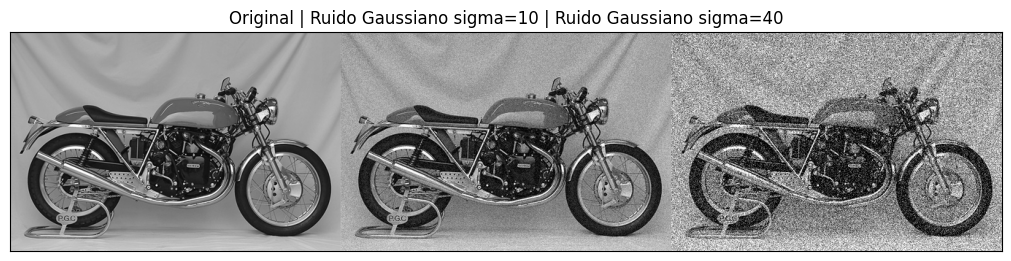

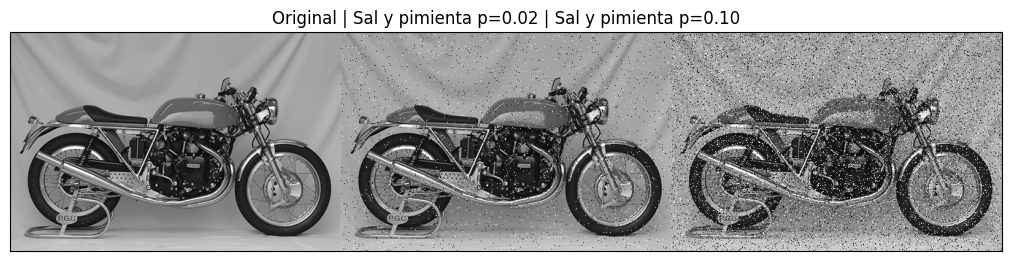

In [ ]:
# Para que los resultados sean reproducibles
rng = np.random.default_rng(1234)

# Leemos motorcycle.bmp en escala de grises usando la función de apoyo
im = readIm(get_image('motorcycle.bmp'), 0)


# ----------------------------------------------------------
# Funciones para introducir ruido
# ----------------------------------------------------------

def gaussian_noise(im, sigma):
    """
    Añade ruido Gaussiano de media 0 y desviación típica sigma.
    Es importante aplicar np.clip al resultado, de modo que nos aseguremos de
    que los niveles de gris válidos estén entre 0 y 255.
    """
    # A CUBRIR POR EL ALUMNADO

    return noisy.astype(np.uint8)


def salt_pepper_noise(im, probability):
    """
    Sustituye una proporción 'probability' de píxeles por
    negro (0) o blanco (255), con igual probabilidad.
    Por ejemplo, si:
      probability = 0.10
    entonces:
      aproximadamente un 5% de los píxeles se pone a 0 (pimienta);
      aproximadamente otro 5% se pone a 255 (sal);
      el resto conserva su valor original.
    Por tanto, probability representa aproximadamente la proporción total de
    píxeles corrompidos, no la probabilidad de sal y la probabilidad de pimienta por separado.
    """
    # A CUBRIR POR EL ALUMNADO

    return noisy


# Dos niveles diferentes para cada tipo de ruido
gauss_10 = gaussian_noise(im, sigma=10)
gauss_40 = gaussian_noise(im, sigma=40)

sp_002 = salt_pepper_noise(im, probability=0.02)
sp_010 = salt_pepper_noise(im, probability=0.10)


# ----------------------------------------------------------
# Visualización usando las funciones proporcionadas
# ----------------------------------------------------------

displayMI_ES(
    [im, gauss_10, gauss_40],
    title='Original | Ruido Gaussiano sigma=10 | Ruido Gaussiano sigma=40',
    factor=2
)

displayMI_ES(
    [im, sp_002, sp_010],
    title='Original | Sal y pimienta p=0.02 | Sal y pimienta p=0.10',
    factor=2
)

<font color='blue'>2. **Filtrado.** Empleando exclusivamente funciones proporcionadas por OpenCV, aplica a las imágenes ruidosas:

   * <font color='blue'>un filtro de promedio, también llamado `box filter` (`cv2.blur`);
   * un filtro Gaussiano (`cv2.GaussianBlur`);
   * un filtro de mediana (`cv2.medianBlur`).

   <font color='blue'>Experimenta con al menos dos tamaños diferentes de kernel ($5$ y $11$). En el caso del filtro Gaussiano, utiliza los mismos tamaños de kernel y deja que OpenCV calcule automáticamente un valor de $\sigma$ adecuado para cada uno. Compara visualmente los resultados y analiza:

   * <font color='blue'>qué filtros resultan más apropiados para cada tipo de ruido;
   * cómo influye el tamaño del kernel;
   * cuál es el compromiso entre eliminación de ruido y conservación de detalles de la imagen.



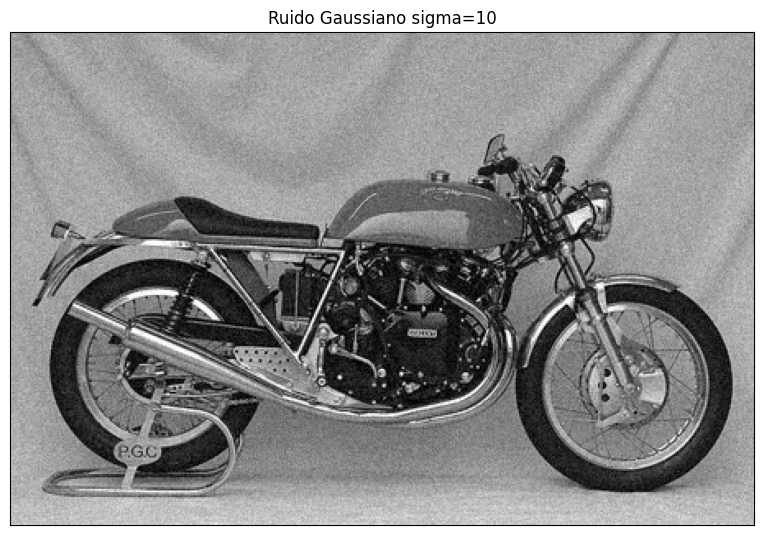

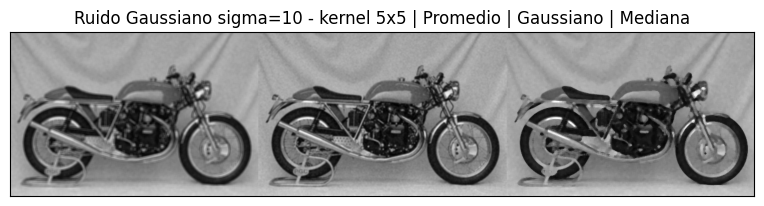

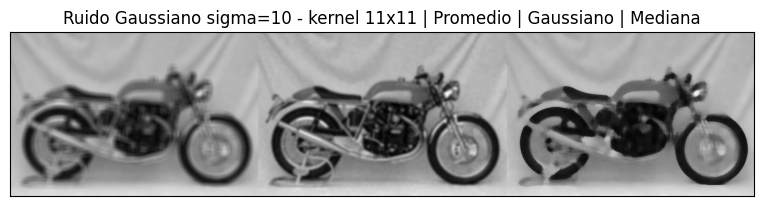

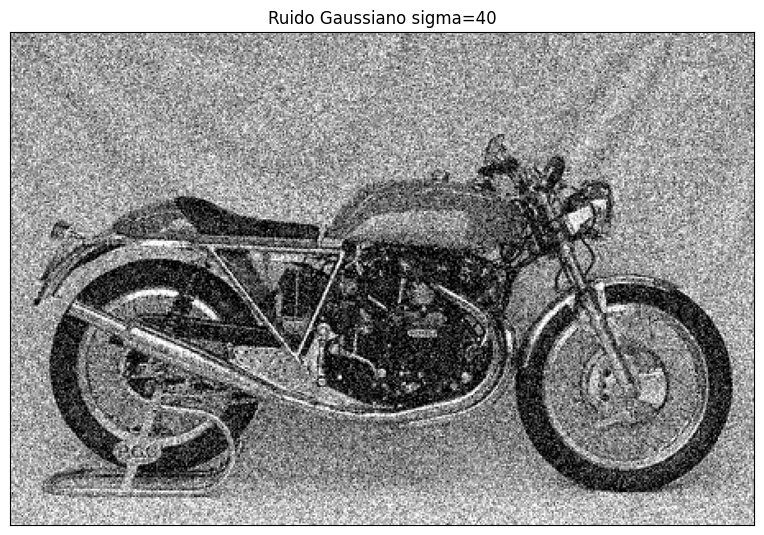

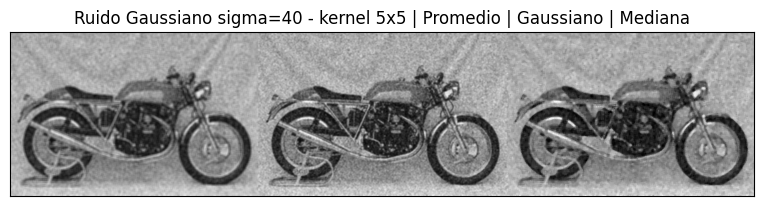

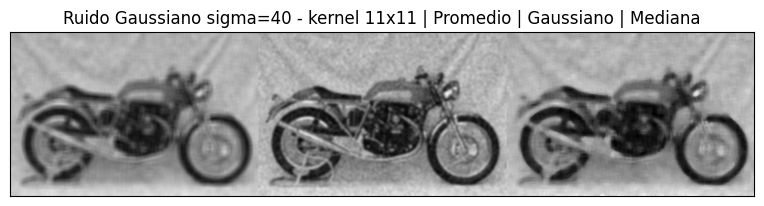

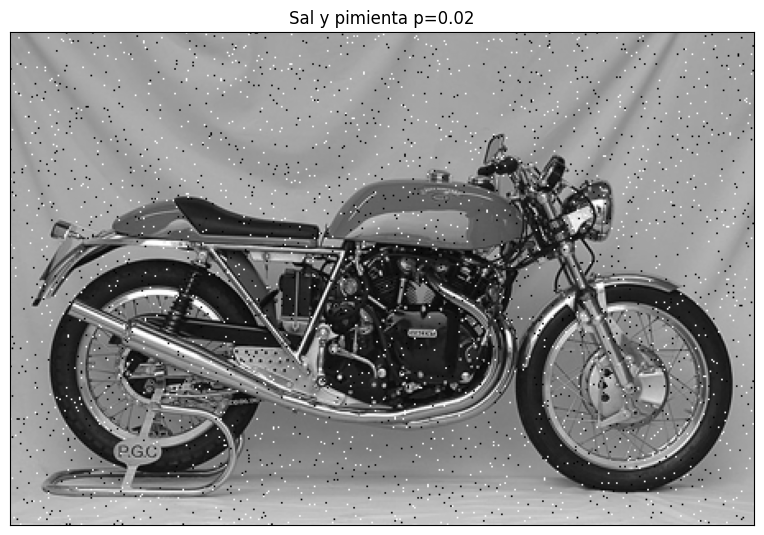

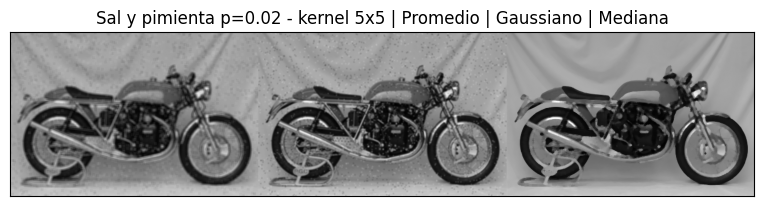

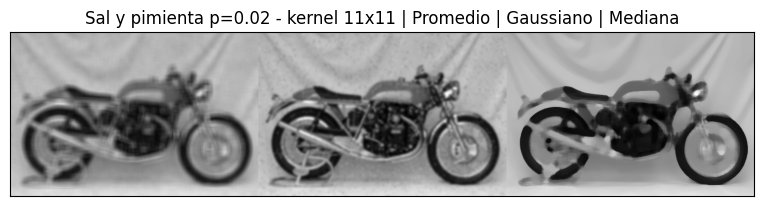

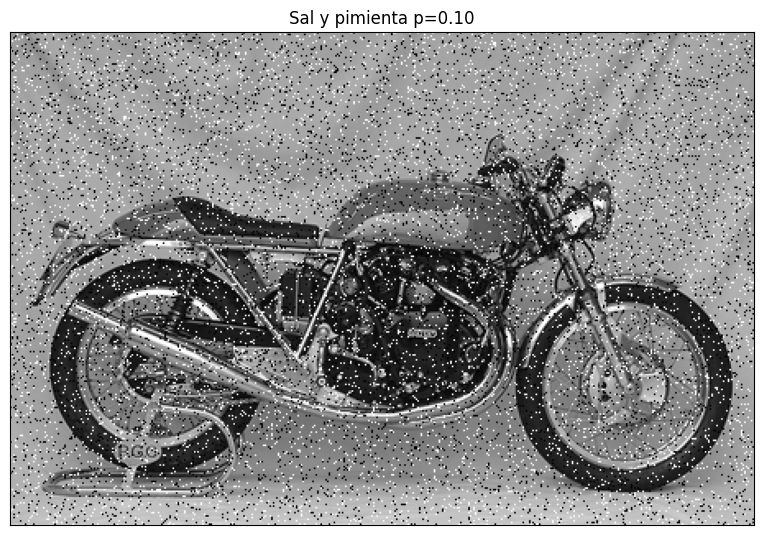

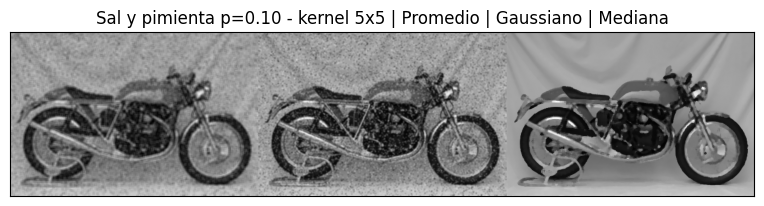

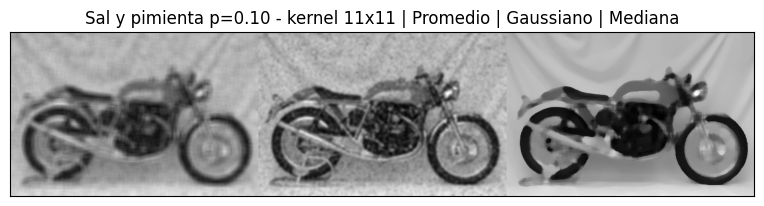

In [ ]:
def apply_filters(im, ksize):
    """
    Aplica los tres filtros solicitados en el enunciado.
    """

    mean = cv2.blur(
        # A CUBRIR POR EL ALUMNADO
    )

    gaussian = cv2.GaussianBlur(
        # A CUBRIR POR EL ALUMNADO
    )

    median = cv2.medianBlur(
        # A CUBRIR POR EL ALUMNADO
    )

    return mean, gaussian, median


def show_filter_results(noisy, description, ksize):
    """
    Muestra conjuntamente los resultados de los tres filtros.
    """

    mean, gaussian, median = apply_filters(noisy, ksize)

    displayMI_ES(
        [mean, gaussian, median],
        title=(description +
               f' - kernel {ksize}x{ksize} | '
               'Promedio | Gaussiano | Mediana'),
        factor=1.5
    )


# Dos tamaños diferentes de kernel
kernel_sizes = [5, 11]

noisy_images = [
    (gauss_10, 'Ruido Gaussiano sigma=10'),
    (gauss_40, 'Ruido Gaussiano sigma=40'),
    (sp_002, 'Sal y pimienta p=0.02'),
    (sp_010, 'Sal y pimienta p=0.10')
]


# A CUBRIR POR EL ALUMNADO

<font color='blue'>3. **Ruido, suavizado y detección de bordes.** Utiliza el operador Sobel de OpenCV (`cv2.Sobel`), tanto con kernels de tamaño $3\times3$ y $11\times11$, para obtener la magnitud del gradiente (`cv2.magnitude`) de:

   * <font color='blue'>la imagen original;
   * una de las imágenes con ruido Gaussiano ($\sigma=40$);
   * esa misma imagen después de aplicar un filtrado Gaussiano ($5\times5$);
   * una imagen afectada por ruido sal y pimienta ($p=0.10$);
   * esa misma imagen después de aplicar un filtro de mediana ($5\times5$).

   <font color='blue'>Compara los resultados y explica qué efecto tiene el ruido sobre la detección de bordes, así como el impacto que tiene el tamaño del kernel de derivadas, y por qué puede ser conveniente realizar un suavizado antes de calcular derivadas.

In [ ]:
def sobel_magnitude(im, ksize):
    """
    Calcula la magnitud del gradiente utilizando Sobel
    con un kernel de tamaño ksize x ksize.
    """

    gx = cv2.Sobel(
        # A CUBRIR POR EL ALUMNADO
    )

    gy = cv2.Sobel(
        # A CUBRIR POR EL ALUMNADO
    )

    magnitude = cv2.magnitude(# A CUBRIR POR EL ALUMNADO)

    return magnitude

In [ ]:
# Ruido Gaussiano -> suavizado Gaussiano
gauss_filtered = cv2.GaussianBlur(
    # A CUBRIR POR EL ALUMNADO
)

# Ruido sal y pimienta -> filtro de mediana
sp_filtered = cv2.medianBlur(
    # A CUBRIR POR EL ALUMNADO
)

In [ ]:
for ksize in [3, 11]:

    # A CUBRIR POR EL ALUMNADO

## <font color='blue'>B) Discretización de kernels Gaussianos 1D (1.5 puntos)

<font color='blue'>En este apartado se deben realizar las siguientes tareas (evitando, en todo momento, el uso de funciones de OpenCV):

1. Calcular las máscaras discretas 1D de la Gaussiana, así como su primera y segunda derivadas (con la escala normalizada), considerando que la entrada a dicha función de creación de máscaras 1D puede ser tanto un posible sigma como un posible tamaño de máscara. Se proporcionará exactamente uno de los dos parámetros, $\sigma$ o $T$. El tamaño $T$ será siempre impar. Se debe exlicar detalladamente el proceso seguido a la hora de discretizar los kernels Gaussianos.
2. Emplear los siguientes valores de sigma ($\{0.25, 1.5, 4, 8, 16\}$) y los siguientes valores de tamaño de máscara ($\{3,5,7,15\}$), y mostrar el perfil (es decir, la silueta de las máscaras como funciones 1D) para verificar que las máscaras creadas son correctas.
3. Describir/explicar/analizar si las formas de dichos kernels tienen sentido y se corresponden con lo que esperaríamos ver.
4. ¿De qué manera se normalizan las derivadas de orden 0, 1 y 2; y qué ocurre, es decir, cuál es el efecto, si no se realizan estas normalizaciones?

<font color='blue'>La aplicación y uso de estos kernels 1D lo veremos en la práctica 2 de la asignatura.

In [ ]:
"""
    Evalúa la función Gaussiana 1D de media cero para una posición x
    y una desviación estándar sigma.
"""
def GaussFunc(x,sigma):
    # A CUBRIR POR EL ALUMNADO

"""
    Evalúa la primera derivada de la función Gaussiana 1D de media cero
    para una posición x y una desviación estándar sigma.
"""
def GaussDeriv1Func(x,sigma):
    # A CUBRIR POR EL ALUMNADO

"""
    Evalúa la segunda derivada de la función Gaussiana 1D de media cero
    para una posición x y una desviación estándar sigma.
"""
def GaussDeriv2Func(x,sigma):
    # A CUBRIR POR EL ALUMNADO

"""
    Construye un kernel Gaussiano 1D discreto, o una de sus derivadas,
    a partir de sigma o del tamaño deseado para la máscara.

    El parámetro order determina el tipo de kernel:
        order = 0 -> Gaussiana
        order = 1 -> primera derivada de la Gaussiana
        order = 2 -> segunda derivada de la Gaussiana

    Debe proporcionarse sigma o sizeMask, pero no ambos simultáneamente.
    Si solamente se proporciona sigma, debe determinarse un tamaño
    apropiado para el kernel. Si solamente se proporciona sizeMask,
    debe obtenerse un valor apropiado de sigma.

    El kernel debe construirse discretizando la función correspondiente
    en las posiciones espaciales que forman la máscara y debe aplicarse
    la normalización apropiada según el orden de la derivada.
"""
def gaussianMask1D(sigma=0, sizeMask=0, order=0):
    # A CUBRIR POR EL ALUMNADO

    return mask

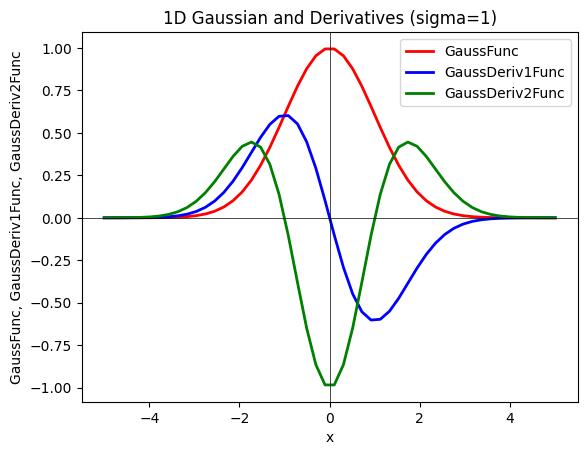

In [ ]:
# Con la siguiente figura verificamos que las funciones Gaussianas implementadas son correctas
plt.figure()
xvalues = np.linspace(-5, 5)
yvalues1 = GaussFunc(xvalues,1)
yvalues2 = GaussDeriv1Func(xvalues,1)
yvalues3 = GaussDeriv2Func(xvalues,1)
plt.plot(xvalues, yvalues1, lw=2, color='red',
label='GaussFunc')
plt.plot(xvalues, yvalues2, lw=2, color='blue',
label='GaussDeriv1Func')
plt.plot(xvalues, yvalues3, lw=2, color='green',
label='GaussDeriv2Func')
plt.title('1D Gaussian and Derivatives (sigma=1)')
plt.xlabel('x')
plt.ylabel('GaussFunc, GaussDeriv1Func, GaussDeriv2Func')
plt.axhline(0, lw=0.5, color='black')
plt.axvline(0, lw=0.5, color='black')
plt.legend();

FIJAMOS PRIMERO EL TAMAÑO DE LA MÁSCARA


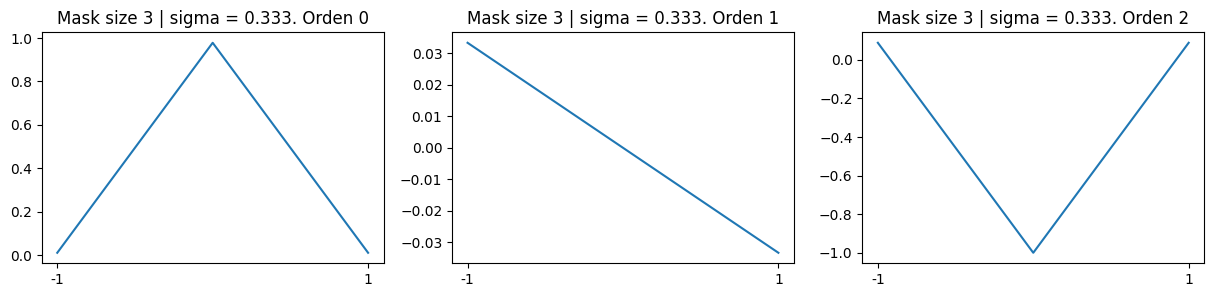

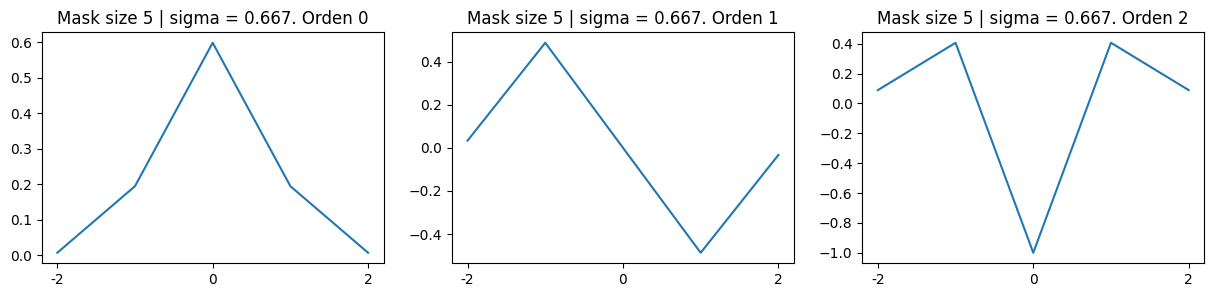

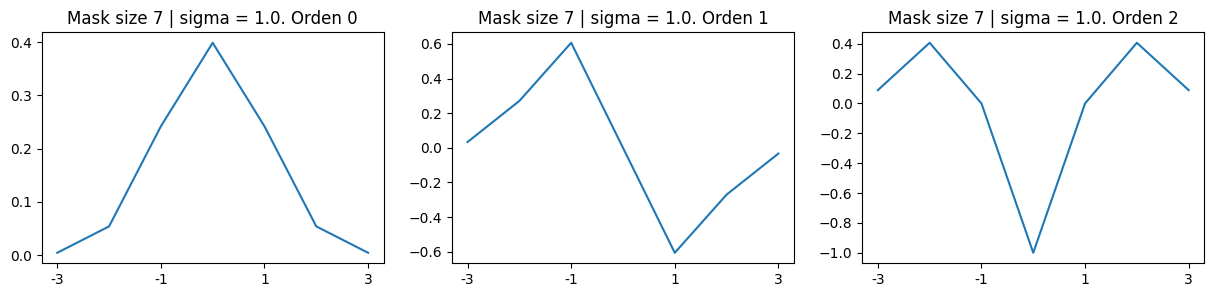

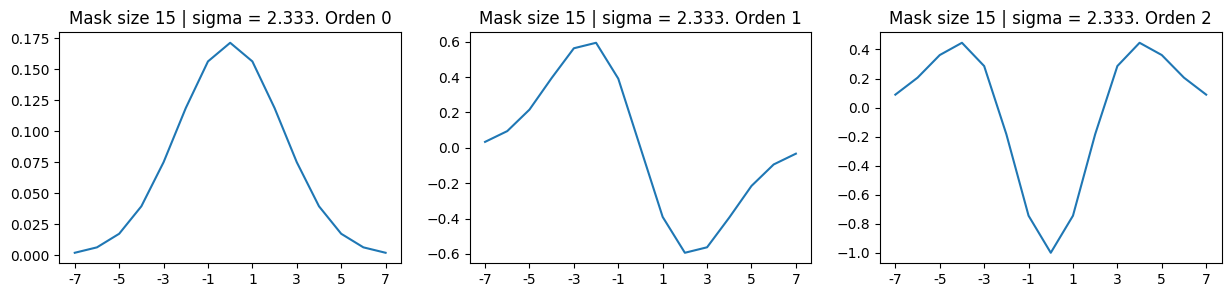

FIJAMOS AHORA EL SIGMA


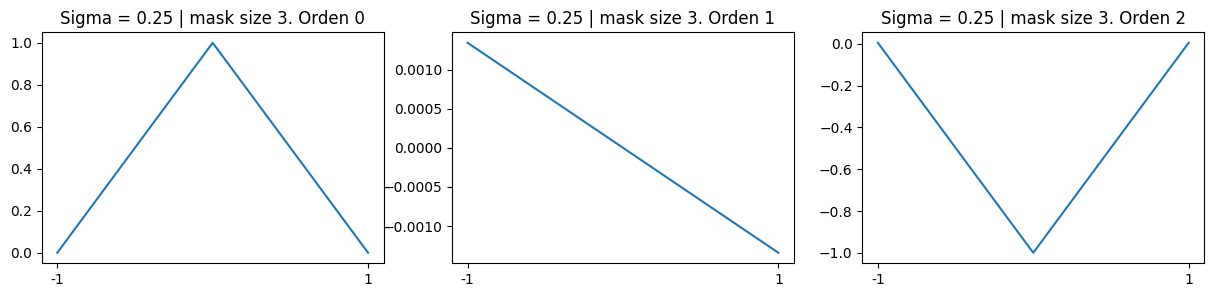

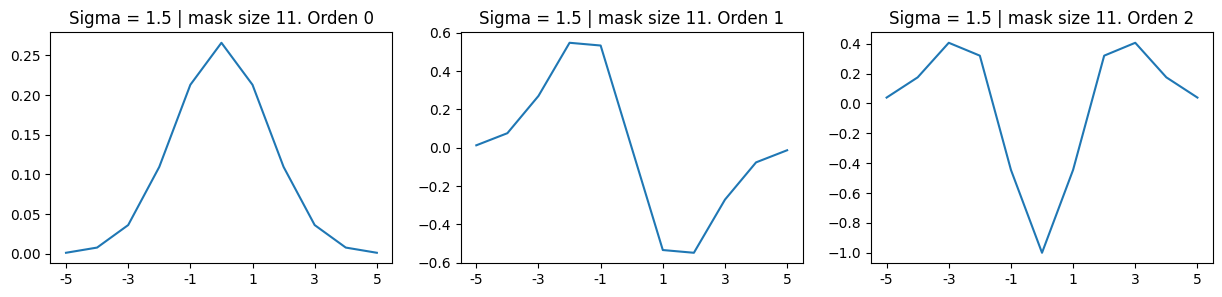

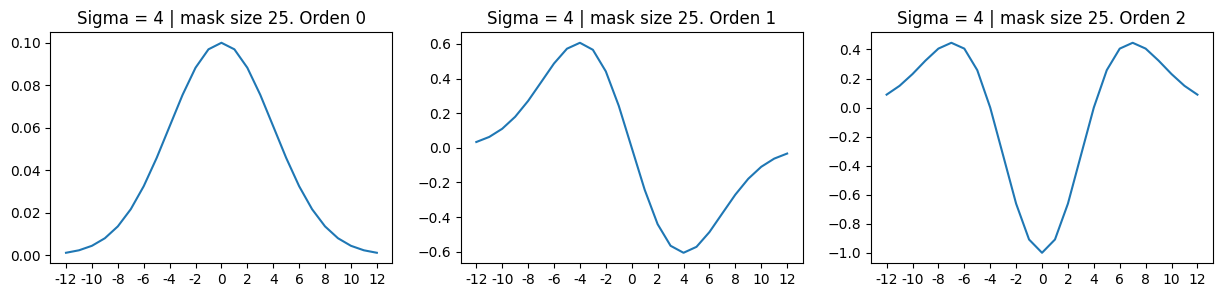

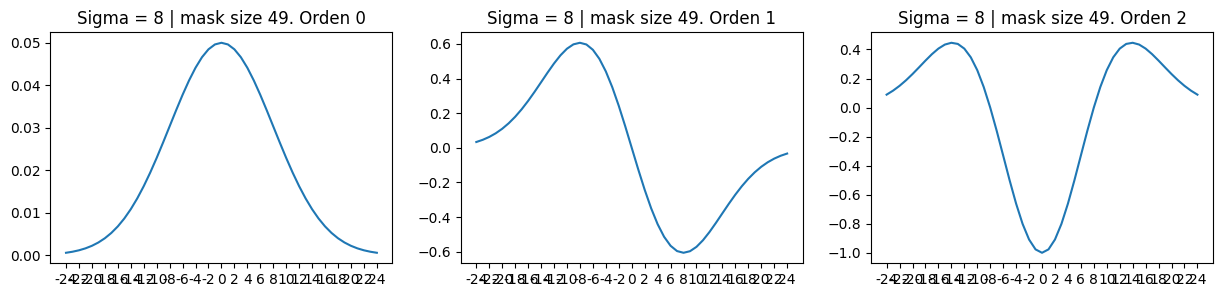

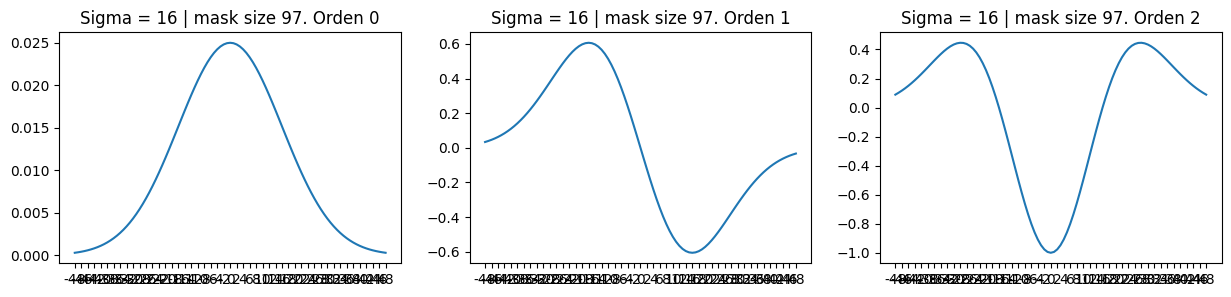

In [ ]:
sigma_values = [# A CUBRIR POR EL ALUMNADO]
size_masks = [# A CUBRIR POR EL ALUMNADO]

plt.rcParams["figure.figsize"] = (15,3) # para ajustar tamaño del ancho y alto (ejes)
print('FIJAMOS PRIMERO EL TAMAÑO DE LA MÁSCARA')
for sizeMask in size_masks:
  # A CUBRIR POR EL ALUMNADO
  plt.show() # mostrar todas de golpe como un subplots

print('FIJAMOS AHORA EL SIGMA')
for sigma in sigma_values:
  # A CUBRIR POR EL ALUMNADO
  plt.show() # mostrar todas de golpe como un subplots